## Introduction

We start our code by importing required packages 

- <code>pyscf</code>, <code>openfermion</code>: To load the hamiltonian geometry and get the fermionic and qubit Hamiltonian
- <code>cse</code>: For the Hamiltonian reduction 

In [1]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from typing import Iterator, Dict, Tuple, List, Callable, Optional, Sequence, Union

from pyscf import gto, scf, ao2mo, mcscf

import cirq
from openfermion import FermionOperator, jordan_wigner, get_sparse_operator
from scipy.sparse import csr_matrix
import scipy.linalg

from qiskit.quantum_info import SparsePauliOp
from qiskit_nature.second_q.operators import ElectronicIntegrals
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.mappers import JordanWignerMapper


## Run the subroutine

In [2]:
%run "./LinLin_channel.ipynb"

wmax = 2.27456767
T_filter = 1.38118232
number of nonzero Fourier terms = 101

first few filter terms:
k=-99, c_k=-6.491268506973085e-05j
k=-97, c_k=-0.00013497258824897714j
k=-95, c_k=-0.0002103924345770992j
k=-93, c_k=-0.00029139557231845306j
k=-91, c_k=-0.00037821741492743315j
k=-89, c_k=-0.00047110710140819506j
k=-87, c_k=-0.0005703294094046108j
k=-85, c_k=-0.0006761669617415852j

first few gate parameters:
k=-99, c_k= 0-6.49127e-05j, theta_k=0.00001026, phi_k=-1.57079633
k=-97, c_k= 0-0.000134973j, theta_k=0.00002134, phi_k=-1.57079633
k=-95, c_k= 0-0.000210392j, theta_k=0.00003327, phi_k=-1.57079633
k=-93, c_k= 0-0.000291396j, theta_k=0.00004607, phi_k=-1.57079633
k=-91, c_k= 0-0.000378217j, theta_k=0.00005980, phi_k=-1.57079633
k=-89, c_k= 0-0.000471107j, theta_k=0.00007449, phi_k=-1.57079633
k=-87, c_k= 0-0.000570329j, theta_k=0.00009018, phi_k=-1.57079633
k=-85, c_k= 0-0.000676167j, theta_k=0.00010691, phi_k=-1.57079633
<class 'cirq.circuits.circuit.Circuit'>
273086000


## Molecular Hamiltonian

In [5]:
builder = HamiltonianBuilder()

mol = builder.build_molecule(
    geometry = [('H', (-2.3367346938775513, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (2.4032653061224485, 0.0, 0.0))],
    basis="sto-3g",
    multiplicity=2,
    charge=0,
    active_indices=None,
    ancilla_index=0,
    n_active_electrons=None,
    n_active_orbitals=None,
    use_casscf_orbitals=True,
)

interaction_ham, fermion_ham, qubit_ham, H_mat, E_corr, n_system, ancilla, system_qubits = (
    mol.interaction, mol.fermion, mol.qubit, mol.matrix, mol.energy,
    mol.n_system, mol.ancilla, mol.system_qubits
)

In [6]:
E_corr, n_system, ancilla, system_qubits

(-1.405454080155143,
 6,
 cirq.LineQubit(0),
 [cirq.LineQubit(1),
  cirq.LineQubit(2),
  cirq.LineQubit(3),
  cirq.LineQubit(4),
  cirq.LineQubit(5),
  cirq.LineQubit(6)])

### We keep the <code>E_nc_classical</code> by direct diagonalization of the non-contextual easy Hamiltonian, and keep working with the <code>H_c</code> for the quantum part, calculate the gs energy and add it to the <code>E_nc_classical</code> to get the total energy.

In [8]:
'''from ham_reduce2  import reduce_hamiltonian


qubit_ham_red, fermion_ham_red, _ = reduce_hamiltonian(qubit_ham, fermion_ham)
qubit_ham_c_red, fermion_ham_c_red, E_nc_classical = reduce_hamiltonian(qubit_ham, fermion_ham)


Hc_red_mat = get_sparse_operator(qubit_ham_c_red).toarray()
E_corr = np.min(np.linalg.eigvalsh(Hc_red_mat))

E_total = E_nc_classical + E_corr

# Sparse matrix
H_sparse = get_sparse_operator(qubit_ham_c_red)
H_mat = H_sparse.toarray()'''

'from ham_reduce2  import reduce_hamiltonian\n\n\nqubit_ham_red, fermion_ham_red, _ = reduce_hamiltonian(qubit_ham, fermion_ham)\nqubit_ham_c_red, fermion_ham_c_red, E_nc_classical = reduce_hamiltonian(qubit_ham, fermion_ham)\n\n\nHc_red_mat = get_sparse_operator(qubit_ham_c_red).toarray()\nE_corr = np.min(np.linalg.eigvalsh(Hc_red_mat))\n\nE_total = E_nc_classical + E_corr\n\n# Sparse matrix\nH_sparse = get_sparse_operator(qubit_ham_c_red)\nH_mat = H_sparse.toarray()'

In [9]:
#E_total

In [10]:
'''from openfermion import QubitOperator
from openfermion.transforms import reverse_jordan_wigner

H_nc = (
    -2.0 * QubitOperator("Z0")
    -1.5 * QubitOperator("Z1")
    -0.8 * QubitOperator("Z0 Z1")
)

H_c = (
    0.40 * QubitOperator("X2 X3")
    + 0.30 * QubitOperator("Y2 Y3")
    + 0.20 * QubitOperator("Z0 X2")
    + 0.10 * QubitOperator("Z1 Z2")
    + 0.05 * QubitOperator("Z0 Z1 Z3")
    + 0.07 * QubitOperator("X0 X2")
    + 0.09 * QubitOperator("X1 Z3")
    + 0.06 * QubitOperator("Z0 Z1 X2 X3")
)

H_total = H_nc + H_c

H_total_ferm = reverse_jordan_wigner(H_total)

import importlib
import ham_reduce

importlib.reload(ham_reduce)

result = ham_reduce.reduce_hamiltonian(
    H_total,
    H_total_ferm,
    method="energy_window",
    Delta_E=0.1,
    verbose=True,
)'''

'from openfermion import QubitOperator\nfrom openfermion.transforms import reverse_jordan_wigner\n\nH_nc = (\n    -2.0 * QubitOperator("Z0")\n    -1.5 * QubitOperator("Z1")\n    -0.8 * QubitOperator("Z0 Z1")\n)\n\nH_c = (\n    0.40 * QubitOperator("X2 X3")\n    + 0.30 * QubitOperator("Y2 Y3")\n    + 0.20 * QubitOperator("Z0 X2")\n    + 0.10 * QubitOperator("Z1 Z2")\n    + 0.05 * QubitOperator("Z0 Z1 Z3")\n    + 0.07 * QubitOperator("X0 X2")\n    + 0.09 * QubitOperator("X1 Z3")\n    + 0.06 * QubitOperator("Z0 Z1 X2 X3")\n)\n\nH_total = H_nc + H_c\n\nH_total_ferm = reverse_jordan_wigner(H_total)\n\nimport importlib\nimport ham_reduce\n\nimportlib.reload(ham_reduce)\n\nresult = ham_reduce.reduce_hamiltonian(\n    H_total,\n    H_total_ferm,\n    method="energy_window",\n    Delta_E=0.1,\n    verbose=True,\n)'

In [11]:
#qubit_ham_red

## Getting the coefficients

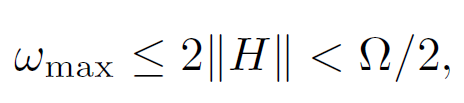

In [7]:
tau_k = 0.1

wmax = 2 * np.linalg.norm(H_mat, ord=2)


sq_filter = SquareWaveFilter()

filter_data = sq_filter.get_coefficients(
    L=wmax,
    K=100,
    tau=tau_k,
    A=1.0,
    window="lanczos",
    drop_zeros=True,
    sign=+1,
)

omega_filter = filter_data["omega_filter"]
cvals = filter_data["cvals"]
ks_filter = filter_data["ks_filter"]
filter_terms = filter_data["filter_terms"]

theta_filter = filter_data["theta_filter"]
phi_filter = filter_data["phi_filter"]
filter_gate_params = filter_data["filter_gate_params"]
T_filter = filter_data["T_filter"]

print(f"wmax = {wmax:.8f}")
print(f"T_filter = {T_filter:.8f}")
print(f"number of nonzero Fourier terms = {len(filter_terms)}")

print("\nfirst few filter terms:")
for k, ck in filter_terms[:8]:
    print(f"k={k:3d}, c_k={ck}")

print("\nfirst few gate parameters:")
for k, ck, theta_k, phi_k in filter_gate_params[:8]:
    print(
        f"k={k:3d}, c_k={ck: .6g}, "
        f"theta_k={theta_k:.8f}, phi_k={phi_k:.8f}"
    )

wmax = 2.81090816
T_filter = 1.11764329
number of nonzero Fourier terms = 101

first few filter terms:
k=-99, c_k=-6.491268506973085e-05j
k=-97, c_k=-0.00013497258824897714j
k=-95, c_k=-0.0002103924345770992j
k=-93, c_k=-0.00029139557231845306j
k=-91, c_k=-0.00037821741492743315j
k=-89, c_k=-0.00047110710140819506j
k=-87, c_k=-0.0005703294094046108j
k=-85, c_k=-0.0006761669617415852j

first few gate parameters:
k=-99, c_k= 0-6.49127e-05j, theta_k=0.00001026, phi_k=-1.57079633
k=-97, c_k= 0-0.000134973j, theta_k=0.00002134, phi_k=-1.57079633
k=-95, c_k= 0-0.000210392j, theta_k=0.00003327, phi_k=-1.57079633
k=-93, c_k= 0-0.000291396j, theta_k=0.00004607, phi_k=-1.57079633
k=-91, c_k= 0-0.000378217j, theta_k=0.00005980, phi_k=-1.57079633
k=-89, c_k= 0-0.000471107j, theta_k=0.00007449, phi_k=-1.57079633
k=-87, c_k= 0-0.000570329j, theta_k=0.00009018, phi_k=-1.57079633
k=-85, c_k= 0-0.000676167j, theta_k=0.00010691, phi_k=-1.57079633


### Getting the plot

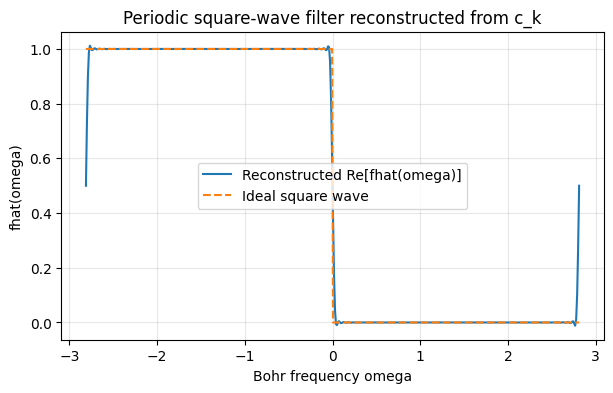

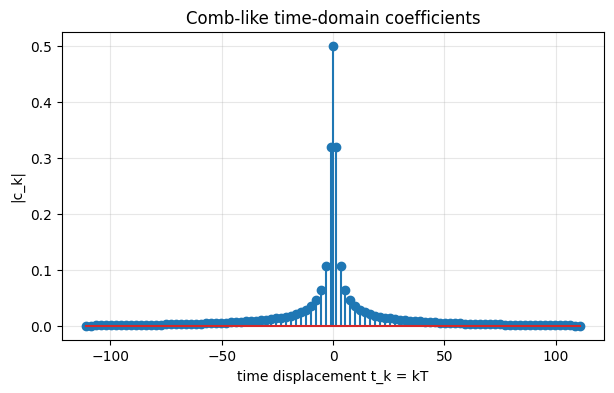

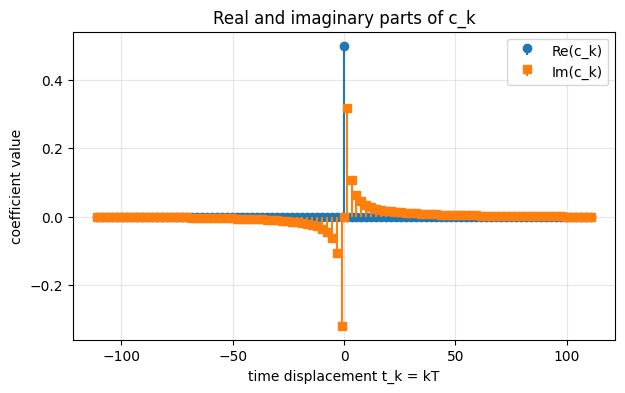

In [8]:
sq_filter.plot(filter_data, num_points=500)

In [9]:
H_sys_psum = fast_qubit_op_to_paulisum(qubit_ham, system_qubits)
H_sys_mat = pauli_sum_matrix(H_sys_psum, system_qubits)

In [15]:
k, ck = filter_terms[0]

circuit, qubits = A_ckt(
    k=k,
    ck=ck,
    tau_s=tau_k,
    jump_type="Ax",
)

print(circuit)

0: ───Rz(-0.5π)───H───@────────────────────────@───H───Rz(0.5π)───
                      │                        │
1: ───────────────────@───FSim(3.27e-06π, 0)───@──────────────────
                          │
2: ───────────────────────FSim(3.27e-06π, 0)──────────────────────


In [16]:
filter_terms[50]

(0, (0.5+0j))

In [17]:
pairs = [(0, 1, "Ax"), (0, 1, "Ay")]
weights = [0.5, 0.5]

W_circuit = build_W_circuit(
    ancilla=ancilla,
    system_qubits=system_qubits,
    H_int=interaction_ham,
    tau_s=tau_k,
    filter_terms=filter_terms,
    pairs=pairs,
    weights=weights,
    reps=None,
    trotter_steps_H=1,
    seed=123,
    T_filter=T_filter,
)

#print(W_circuit)

In [18]:
len(system_qubits)

4

## Run the main class

In [10]:
diag = WChainDiagnostics(
    system_qubits=system_qubits,
    H_int=interaction_ham,
    anc=ancilla,
    H_mat_sys=H_mat,
    n_system=n_system,
    filter_terms=filter_terms,
    T_filter=T_filter,
    tau=tau_k,
    E_corr=E_corr,
    occ_spin_orbs=[0, 1],
    N_applications=10,
    reps_per_W=1,
    trotter_steps_H=1,
    rng_seed=123,
    mol=mol if "mol" in globals() else None,
    geometry=geometry if "geometry" in globals() else None,
)

In [20]:
#diag.circuit_vs_matrix_plot(rerun=False)

In [21]:
#results = diag.three_way_comparison_report(rerun_circuit_matrix=False)

#
# 
# results = diag.three_way_comparison_report(rerun_circuit_matrix=False,exact=True,report=True)

# Example for checking

In [12]:
pairs = [(0, 2, 'Ax'), (0, 3, 'Ax'), (1, 2, 'Ax'), (1, 3, 'Ax'), (0, 2, 'Ay'), (0, 3, 'Ay'), (1, 2, 'Ay'), (1, 3, 'Ay')]
weights = [0.125] * len(pairs)

In [23]:
'''results_order = diag.parameter_sweep_subfigures(
    diff_occ=False,
    diff_order=True,
    diff_reps=False,
    trotter_orders=[1, 2],
)'''

'results_order = diag.parameter_sweep_subfigures(\n    diff_occ=False,\n    diff_order=True,\n    diff_reps=False,\n    trotter_orders=[1, 2],\n)'

In [24]:
'''results_reps = diag.parameter_sweep_subfigures(
    diff_occ=False,
    diff_order=False,
    diff_reps=True,
    reps_per_W_list=[10],
    exact=False
)'''

'results_reps = diag.parameter_sweep_subfigures(\n    diff_occ=False,\n    diff_order=False,\n    diff_reps=True,\n    reps_per_W_list=[10],\n    exact=False\n)'

In [25]:
'''results_occ_reps = diag.parameter_sweep_subfigures(
    diff_occ=True,
    diff_order=False,
    diff_reps=False,
    occ_spin_orbs_list=[
        [2, 3, 4, 5],
        [0, 1],
        [0, 1, 2],
        [0, 1, 2, 3],
        [0, 1, 2, 3, 4],
        [1, 2, 3, 4],
    ],
    reps_per_W_list=5,
)'''

'results_occ_reps = diag.parameter_sweep_subfigures(\n    diff_occ=True,\n    diff_order=False,\n    diff_reps=False,\n    occ_spin_orbs_list=[\n        [2, 3, 4, 5],\n        [0, 1],\n        [0, 1, 2],\n        [0, 1, 2, 3],\n        [0, 1, 2, 3, 4],\n        [1, 2, 3, 4],\n    ],\n    reps_per_W_list=5,\n)'

In [26]:
'''drift_rows = one_step_eigenstate_energy_drifts(
    diag,
    basic=basic,
    W_cache=W_cache,
)'''

'drift_rows = one_step_eigenstate_energy_drifts(\n    diag,\n    basic=basic,\n    W_cache=W_cache,\n)'

In [27]:
# filter_leakage_info = filter_leakage_diagnostics(diag)


#filter_leakage_info = filter_leakage_diagnostics(diag, print_summary=False, make_plots=False)
# filter_leakage_info = filter_leakage_diagnostics(diag, candidate_reps=[1, 3, 5, 9, 15, 25, 50])

Creating the subspace of sets $s$ which restricts the entire Hilbert space 
to the condition when $L$ = Total orbitals, $N_{\alpha}$ = Number of $\alpha$ electrons, $N_{\beta}$ = Number of $\beta$ electrons

In [28]:
L = 4
N_alpha = 2
N_beta = 1

s = basis_alpha_beta(L, N_alpha, N_beta)
s

array([ 7, 13], dtype=uint32)

In [29]:
# Decode the bitstrings
for bitstring in s:
    print(f"Bitstring: {bin(bitstring)[2:].zfill(L)}")

Bitstring: 0111
Bitstring: 1101


## Interpreting the Bitstrings

Here $L = 4$ spin-orbitals total: 2 α (even bits) and 2 β (odd bits).

| Bit index | 3 | 2 | 1 | 0 |
|-----------|---|---|---|---|
| Spin      | β | α | β | α |
| Orbital   | 1 | 1 | 0 | 0 |

---

### Bitstring: `0111`

| Bit index | 3 | 2 | 1 | 0 |
|-----------|---|---|---|---|
| Spin      | β | α | β | α |
| Orbital   | 1 | 1 | 0 | 0 |
| Occupied? | 0 | 1 | 1 | 1 |

Bits 0, 1, 2 are set → **α spin-orbital 0, β spin-orbital 0, α spin-orbital 1** are occupied.  
$N_\alpha = 2$ (spin-orbitals 0, 2) and $N_\beta = 1$ (spin-orbital 1). ✓

---

### Bitstring: `1101`

| Bit index | 3 | 2 | 1 | 0 |
|-----------|---|---|---|---|
| Spin      | β | α | β | α |
| Orbital   | 1 | 1 | 0 | 0 |
| Occupied? | 1 | 1 | 0 | 1 |

Bits 0, 2, 3 are set → **α spin-orbital 0, α spin-orbital 1, β spin-orbital 1** are occupied.  
$N_\alpha = 2$ (spin-orbitals 0, 2) and $N_\beta = 1$ (spin-orbital 3). ✓

---

### Summary

$L = 4$ spin-orbitals, giving 2 α slots (bits 0, 2) and 2 β slots (bits 1, 3).  
Both determinants have $N_\alpha = 2,\ N_\beta = 1$, but the $\beta$ electron
occupies a different spin-orbital:

| Bitstring | α occupied (bits) | β occupied (bit) |
|-----------|-------------------|------------------|
| `0111`    | 0, 2              | 1 (β spin-orbital 0) |
| `1101`    | 0, 2              | 3 (β spin-orbital 1) |

These are the only two valid Slater determinants for $L = 4,\ N_\alpha = 2,\ N_\beta = 1$,
since there is only $\binom{2}{2} = 1$ way to fill the α slots
and $\binom{2}{1} = 2$ ways to place the single β electron.

# Define the subspace where $N_{\alpha}=N_{\beta}$ for a given $L$

In [30]:
L = 4

s_closed = []
for N in range(L // 2 + 1):          # N = 0, 1, 2  (can't exceed available α or β slots)
    dets = basis_alpha_beta(L, N, N)
    s_closed.append(dets)
    print(f"N_α = N_β = {N}  →  {len(dets)} determinants")

s_closed = np.concatenate(s_closed)
#print(f"\nTotal determinants in closed-shell subspace: {len(s_closed)}")
s_closed

N_α = N_β = 0  →  1 determinants
N_α = N_β = 1  →  4 determinants
N_α = N_β = 2  →  1 determinants


array([ 0,  3,  6,  9, 12, 15], dtype=uint32)

## Hydrogen dissociation

In [31]:
import numpy as np
from pyLIQTR.utils.printing                 import openqasm
from openfermion.chem                       import  MolecularData
from openfermionpyscf                       import  run_pyscf

from pyLIQTR.ProblemInstances.getInstance   import  getInstance
from pyLIQTR.BlockEncodings.getEncoding     import  getEncoding, VALID_ENCODINGS

from pyLIQTR.qubitization.qsvt_dynamics import qsvt_dynamics, simulation_phases
from pyLIQTR.utils.circuit_decomposition    import  circuit_decompose_multi

def struc2ham(structure):
    mol_data = MolecularData(structure,'sto3g',1,0)
    mol = run_pyscf(mol_data, run_scf=1, run_mp2=0, run_cisd=0, run_ccsd=0, run_fci=1, verbose=1)
    mol_ham         =   mol.get_molecular_hamiltonian()
    return mol_ham

def QSVT(mol_ham):
    model    =   getInstance("ChemicalHamiltonian",mol_ham=mol_ham)
    scaled_times = model.alpha
    eps = 0.001

    encoding=getEncoding(VALID_ENCODINGS.PauliLCU)

    phases = simulation_phases(times=scaled_times, eps=eps, precompute=False, phase_algorithm="random")
    gate_qsvt = qsvt_dynamics(encoding=encoding, instance=model, phase_sets=phases)

    print(circuit_decompose_multi(gate_qsvt.circuit, 1))

def displace(coords,dx=0.01,f=3): #dx distance in Angstrom; f number of points
    assert f % 2 == 1 #odd central difference to take 0 to be original coord
    displacements = [i*dx for i in range(-(f-1),f) if i != 0] #displacements from -(f-1) to f-1 without 0
    for i in range(len(coords)):
        for j in range(3):
            for d in displacements:
                new_coord = np.copy(coords)
                new_coord[i][j] += d
                yield new_coord

d = 3.674e-01
atoms = ['H','H']
coords = np.array([[0.0,0.0,d],[0.0,0.0,-d]])
structure = list(zip(atoms,coords))
#run suspected minimum geometry
#QSVT(struc2ham(structure))
#run for each displaced coordinate
displaced_coords = displace(coords,f=3)
for newc in displaced_coords:
    structure = list(zip(atoms,newc))
    print(structure)
    #QSVT(struc2ham(structure))
    
    
geometries = []

displaced_coords = displace(coords, f=3)

for newc in displaced_coords:
    struct = [(atom, tuple(map(float, xyz))) for atom, xyz in zip(atoms, newc)]
    geometries.append(struct)

[('H', array([-0.02  ,  0.    ,  0.3674])), ('H', array([ 0.    ,  0.    , -0.3674]))]
[('H', array([-0.01  ,  0.    ,  0.3674])), ('H', array([ 0.    ,  0.    , -0.3674]))]
[('H', array([0.01  , 0.    , 0.3674])), ('H', array([ 0.    ,  0.    , -0.3674]))]
[('H', array([0.02  , 0.    , 0.3674])), ('H', array([ 0.    ,  0.    , -0.3674]))]
[('H', array([ 0.    , -0.02  ,  0.3674])), ('H', array([ 0.    ,  0.    , -0.3674]))]
[('H', array([ 0.    , -0.01  ,  0.3674])), ('H', array([ 0.    ,  0.    , -0.3674]))]
[('H', array([0.    , 0.01  , 0.3674])), ('H', array([ 0.    ,  0.    , -0.3674]))]
[('H', array([0.    , 0.02  , 0.3674])), ('H', array([ 0.    ,  0.    , -0.3674]))]
[('H', array([0.    , 0.    , 0.3474])), ('H', array([ 0.    ,  0.    , -0.3674]))]
[('H', array([0.    , 0.    , 0.3574])), ('H', array([ 0.    ,  0.    , -0.3674]))]
[('H', array([0.    , 0.    , 0.3774])), ('H', array([ 0.    ,  0.    , -0.3674]))]
[('H', array([0.    , 0.    , 0.3874])), ('H', array([ 0.    ,  

In [32]:
import numpy as np

atoms = ["H", "H"]

def make_H2_geometries(R_min=0.1, R_max=7.0, n_points=50):
    """
    Generate H2 geometries with bond distance R from R_min to R_max.
    The molecule is centered at the origin:
        H -- H along z-axis
        positions: +R/2 and -R/2
    """
    geometries = []

    for R in np.linspace(R_min, R_max, n_points):
        coords = np.array([
            [0.0, 0.0,  R / 2],
            [0.0, 0.0, -R / 2],
        ])

        structure = [
            (atom, tuple(map(float, xyz)))
            for atom, xyz in zip(atoms, coords)
        ]

        geometries.append(structure)

    return geometries


geometries = make_H2_geometries(
    R_min=0.74,
    R_max=5.0,
    n_points=10,
)

for geometry in geometries:
    print(geometry)

[('H', (0.0, 0.0, 0.37)), ('H', (0.0, 0.0, -0.37))]
[('H', (0.0, 0.0, 0.6066666666666667)), ('H', (0.0, 0.0, -0.6066666666666667))]
[('H', (0.0, 0.0, 0.8433333333333333)), ('H', (0.0, 0.0, -0.8433333333333333))]
[('H', (0.0, 0.0, 1.08)), ('H', (0.0, 0.0, -1.08))]
[('H', (0.0, 0.0, 1.3166666666666667)), ('H', (0.0, 0.0, -1.3166666666666667))]
[('H', (0.0, 0.0, 1.5533333333333332)), ('H', (0.0, 0.0, -1.5533333333333332))]
[('H', (0.0, 0.0, 1.79)), ('H', (0.0, 0.0, -1.79))]
[('H', (0.0, 0.0, 2.026666666666667)), ('H', (0.0, 0.0, -2.026666666666667))]
[('H', (0.0, 0.0, 2.263333333333333)), ('H', (0.0, 0.0, -2.263333333333333))]
[('H', (0.0, 0.0, 2.5)), ('H', (0.0, 0.0, -2.5))]


In [33]:
from pyLIQTR.utils.resource_analysis import estimate_resources

In [34]:
'''rho_current = None

all_circuits = []
all_resources = []
all_rhos = []
all_steps = []
all_energies = []
all_E_corr = []

for g_idx, geometry in enumerate(geometries):

    Ham = HamiltonianBuilder().build_molecule(
        geometry=geometry,
        basis="sto-3g",
        multiplicity=1,
        charge=0,
        active_indices=None,
        ancilla_index=0,
        n_active_electrons=None,
        n_active_orbitals=None,
        use_casscf_orbitals=True,
    )

    interaction_ham, fermion_ham, qubit_ham, H_mat, E_corr, n_system, ancilla, system_qubits = (
        Ham.interaction,
        Ham.fermion,
        Ham.qubit,
        Ham.matrix,
        Ham.energy,
        Ham.n_system,
        Ham.ancilla,
        Ham.system_qubits,
    )

    print(f"Geometry {g_idx}: {geometry}")
    print(f"E_corr = {E_corr:.10f} Hartree")

    steps, energies, W_circuits, rho_current = run_W_chain_circuit(
        system_qubits=system_qubits,
        H_int=interaction_ham,
        anc=ancilla,
        tau=0.5,
        filter_terms=filter_terms,
        pairs=pairs,
        weights=weights,
        N_applications=200,
        reps_per_W=10,
        occ_spin_orbs=[0, 1],
        trotter_steps_H=1,
        rng_seed=123 + g_idx,
        T_filter=T_filter,
        H_mat_sys=H_mat,
        initial_rho_sys=rho_current,
    )

    geometry_resources = []

    for c_idx, W_circuit in enumerate(W_circuits):
        resources = estimate_resources(W_circuit)
        geometry_resources.append(resources)

    all_circuits.append(W_circuits)
    all_resources.append(geometry_resources)
    all_rhos.append(rho_current)
    all_steps.append(steps)
    all_energies.append(energies)
    all_E_corr.append(E_corr)'''

'rho_current = None\n\nall_circuits = []\nall_resources = []\nall_rhos = []\nall_steps = []\nall_energies = []\nall_E_corr = []\n\nfor g_idx, geometry in enumerate(geometries):\n\n    Ham = HamiltonianBuilder().build_molecule(\n        geometry=geometry,\n        basis="sto-3g",\n        multiplicity=1,\n        charge=0,\n        active_indices=None,\n        ancilla_index=0,\n        n_active_electrons=None,\n        n_active_orbitals=None,\n        use_casscf_orbitals=True,\n    )\n\n    interaction_ham, fermion_ham, qubit_ham, H_mat, E_corr, n_system, ancilla, system_qubits = (\n        Ham.interaction,\n        Ham.fermion,\n        Ham.qubit,\n        Ham.matrix,\n        Ham.energy,\n        Ham.n_system,\n        Ham.ancilla,\n        Ham.system_qubits,\n    )\n\n    print(f"Geometry {g_idx}: {geometry}")\n    print(f"E_corr = {E_corr:.10f} Hartree")\n\n    steps, energies, W_circuits, rho_current = run_W_chain_circuit(\n        system_qubits=system_qubits,\n        H_int=inter

In [35]:
'''import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(16, 5))

global_step = 0

for g_idx, (steps_g, energies_g, E_corr_g) in enumerate(
    zip(all_steps, all_energies, all_E_corr)
):
    xs = [global_step + s for s in steps_g]

    ax.plot(xs, energies_g, lw=1.5, color='steelblue')
    ax.hlines(E_corr_g, xs[0], xs[-1], colors='steelblue', linestyles=':', lw=1.0, alpha=0.7)

    if g_idx > 0:
        ax.axvline(global_step, color='black', lw=1.5, ls='--', alpha=0.9)

    global_step += steps_g[-1]

ax.set_xlabel('Cumulative W applications', fontsize=12)
ax.set_ylabel(r'$\langle H_g \rangle$  (Hartree)', fontsize=12)
ax.set_title(
    'LinLin circuit — sequential geometries\n'
    'State carried over; Hamiltonian updated at each dashed vertical line',
    fontsize=12
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()'''

"import matplotlib.pyplot as plt\nimport numpy as np\n\nfig, ax = plt.subplots(figsize=(16, 5))\n\nglobal_step = 0\n\nfor g_idx, (steps_g, energies_g, E_corr_g) in enumerate(\n    zip(all_steps, all_energies, all_E_corr)\n):\n    xs = [global_step + s for s in steps_g]\n\n    ax.plot(xs, energies_g, lw=1.5, color='steelblue')\n    ax.hlines(E_corr_g, xs[0], xs[-1], colors='steelblue', linestyles=':', lw=1.0, alpha=0.7)\n\n    if g_idx > 0:\n        ax.axvline(global_step, color='black', lw=1.5, ls='--', alpha=0.9)\n\n    global_step += steps_g[-1]\n\nax.set_xlabel('Cumulative W applications', fontsize=12)\nax.set_ylabel(r'$\\langle H_g \rangle$  (Hartree)', fontsize=12)\nax.set_title(\n    'LinLin circuit — sequential geometries\n'\n    'State carried over; Hamiltonian updated at each dashed vertical line',\n    fontsize=12\n)\nax.grid(True, alpha=0.3)\nplt.tight_layout()\nplt.show()"

In [36]:
'''import numpy as np
import matplotlib.pyplot as plt

# final circuit energy after last W-step for each geometry
final_energies = np.array([energies[-1] for energies in all_energies])

# exact/reference energy for each corresponding Hamiltonian
E_corr_array = np.array(all_E_corr)

# difference: circuit final energy - exact/reference energy
energy_diffs = final_energies - E_corr_array

ham_indices = np.arange(len(energy_diffs))

plt.figure(figsize=(7, 4))
plt.plot(ham_indices, energy_diffs, marker="o")
plt.xlabel("Hamiltonian index / geometry index")
plt.ylabel(r"$E_{\mathrm{final}} - E_{\mathrm{corr}}$")
plt.title("Final energy error along Hamiltonian sequence")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()'''

'import numpy as np\nimport matplotlib.pyplot as plt\n\n# final circuit energy after last W-step for each geometry\nfinal_energies = np.array([energies[-1] for energies in all_energies])\n\n# exact/reference energy for each corresponding Hamiltonian\nE_corr_array = np.array(all_E_corr)\n\n# difference: circuit final energy - exact/reference energy\nenergy_diffs = final_energies - E_corr_array\n\nham_indices = np.arange(len(energy_diffs))\n\nplt.figure(figsize=(7, 4))\nplt.plot(ham_indices, energy_diffs, marker="o")\nplt.xlabel("Hamiltonian index / geometry index")\nplt.ylabel(r"$E_{\\mathrm{final}} - E_{\\mathrm{corr}}$")\nplt.title("Final energy error along Hamiltonian sequence")\nplt.grid(True, alpha=0.3)\nplt.tight_layout()\nplt.show()'

In [37]:
'''import numpy as np
import matplotlib.pyplot as plt

# choose which resource key you want to plot
resource_key = "T"

resource_vs_geometry = []

for geometry_resources in all_resources:
    # total resource over all W-circuits for this Hamiltonian/geometry
    total_resource = sum(res[resource_key] for res in geometry_resources)
    resource_vs_geometry.append(total_resource)

resource_vs_geometry = np.array(resource_vs_geometry)
ham_indices = np.arange(len(resource_vs_geometry))

plt.figure(figsize=(7, 4))
plt.plot(ham_indices, resource_vs_geometry, marker="o")
plt.xlabel("Hamiltonian index / geometry index")
plt.ylabel(f"Total {resource_key}-count")
plt.title(f"Total {resource_key}-count vs Hamiltonian index")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()'''

'import numpy as np\nimport matplotlib.pyplot as plt\n\n# choose which resource key you want to plot\nresource_key = "T"\n\nresource_vs_geometry = []\n\nfor geometry_resources in all_resources:\n    # total resource over all W-circuits for this Hamiltonian/geometry\n    total_resource = sum(res[resource_key] for res in geometry_resources)\n    resource_vs_geometry.append(total_resource)\n\nresource_vs_geometry = np.array(resource_vs_geometry)\nham_indices = np.arange(len(resource_vs_geometry))\n\nplt.figure(figsize=(7, 4))\nplt.plot(ham_indices, resource_vs_geometry, marker="o")\nplt.xlabel("Hamiltonian index / geometry index")\nplt.ylabel(f"Total {resource_key}-count")\nplt.title(f"Total {resource_key}-count vs Hamiltonian index")\nplt.grid(True, alpha=0.3)\nplt.tight_layout()\nplt.show()'

In [38]:
#W_circuits[0]

In [39]:
#len(W_circuits)

## Hydrogen exchange

In [13]:
import numpy as np

atoms = ["H", "H", "H"]

def make_H_exchange_geometries(R_fixed=0.74, R_far=4.0, n_points=50):
    """
    Collinear hydrogen exchange path:

        H1 + H2-H3  ->  H1-H2 + H3

    H2 is fixed at origin.
    H1 approaches from the left.
    H3 leaves to the right.

    At the beginning:
        distance(H2,H3) ≈ R_fixed
        distance(H1,H2) ≈ R_far

    At the end:
        distance(H1,H2) ≈ R_fixed
        distance(H2,H3) ≈ R_far
    """

    geometries = []

    R_left_values = np.linspace(R_far, R_fixed, n_points)
    R_right_values = np.linspace(R_fixed, R_far, n_points)

    for R_left, R_right in zip(R_left_values, R_right_values):

        coords = np.array([
            [-R_left,  0.0, 0.0],   # incoming H
            [ 0.0,     0.0, 0.0],   # central H
            [ R_right, 0.0, 0.0],   # outgoing H
        ])

        structure = [
            (atom, tuple(map(float, xyz)))
            for atom, xyz in zip(atoms, coords)
        ]

        geometries.append(structure)

    return geometries


geometries = make_H_exchange_geometries(
    R_fixed=0.74,
    R_far=4.0,
    n_points=50,
)

for geometry in geometries:
    print(geometry)

[('H', (-4.0, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (0.74, 0.0, 0.0))]
[('H', (-3.933469387755102, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (0.806530612244898, 0.0, 0.0))]
[('H', (-3.8669387755102043, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (0.873061224489796, 0.0, 0.0))]
[('H', (-3.800408163265306, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (0.9395918367346938, 0.0, 0.0))]
[('H', (-3.733877551020408, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (1.0061224489795917, 0.0, 0.0))]
[('H', (-3.66734693877551, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (1.0726530612244898, 0.0, 0.0))]
[('H', (-3.6008163265306123, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (1.1391836734693876, 0.0, 0.0))]
[('H', (-3.5342857142857143, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (1.2057142857142855, 0.0, 0.0))]
[('H', (-3.467755102040816, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (1.2722448979591836, 0.0, 0.0))]
[('H', (-3.4012244897959185, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (1.3387755102040817, 0.0, 0.0)

In [14]:
import numpy as np


def _bond_distance(geometry, i, j):
    """Distance between atoms i and j in a geometry list."""
    ri = np.array(geometry[i][1], dtype=float)
    rj = np.array(geometry[j][1], dtype=float)
    return np.linalg.norm(ri - rj)


def select_ts_centered_window(
    geometries,
    half_width=0.5,
    outside_stride=5,
    keep_endpoints=True,
    return_indices=True,
):
    """
    Select a TS-centered subset of geometries.

    Assumes a 3-atom H-exchange geometry:

        H1 --- H2 --- H3

    where the TS-like geometry is identified by

        distance(H1,H2) ≈ distance(H2,H3).

    The window is a square window in the 2D coordinate

        (R_left, R_right) = (d(H1,H2), d(H2,H3)).

    A geometry is inside the TS window if

        |R_left  - R_TS| <= half_width
        |R_right - R_TS| <= half_width

    All geometries inside the window are kept.
    Outside the window, only every `outside_stride`-th geometry is kept.

    Parameters
    ----------
    geometries:
        List of molecular geometries.

    half_width:
        Half-width of the square TS window in Angstrom.

    outside_stride:
        Downsampling factor outside the TS window.
        Example: outside_stride=5 keeps every 5th outside geometry.

    keep_endpoints:
        If True, always keep first and last geometries.

    return_indices:
        If True, return (selected_geometries, selected_indices, info).
        If False, return only selected_geometries.

    Returns
    -------
    selected_geometries:
        Reduced geometry list.

    selected_indices:
        Indices of selected geometries from the original list.

    info:
        Dictionary containing TS index, TS bond distance, and window data.
    """

    if len(geometries) == 0:
        if return_indices:
            return [], [], {}
        return []

    # ------------------------------------------------------------
    # 1. Compute reaction coordinates:
    #    R_left = d(H1,H2), R_right = d(H2,H3)
    # ------------------------------------------------------------

    R_left = np.array([
        _bond_distance(g, 0, 1)
        for g in geometries
    ])

    R_right = np.array([
        _bond_distance(g, 1, 2)
        for g in geometries
    ])

    # ------------------------------------------------------------
    # 2. Find TS-like middle geometry
    # ------------------------------------------------------------
    # For your path, this is where R_left ≈ R_right.
    # If n_points is even, there may not be an exactly symmetric point,
    # so we choose the closest one.
    # ------------------------------------------------------------

    ts_index = int(np.argmin(np.abs(R_left - R_right)))

    R_ts_left = R_left[ts_index]
    R_ts_right = R_right[ts_index]

    # Use the average as the TS center value.
    R_ts = 0.5 * (R_ts_left + R_ts_right)

    # ------------------------------------------------------------
    # 3. Define square window centered at (R_ts, R_ts)
    # ------------------------------------------------------------

    inside_window = (
        (np.abs(R_left - R_ts) <= half_width)
        &
        (np.abs(R_right - R_ts) <= half_width)
    )

    # ------------------------------------------------------------
    # 4. Keep all inside-window geometries,
    #    keep fewer outside-window geometries
    # ------------------------------------------------------------

    selected_indices = []

    for k in range(len(geometries)):
        if inside_window[k]:
            selected_indices.append(k)
        else:
            if outside_stride is not None and outside_stride > 0:
                if k % outside_stride == 0:
                    selected_indices.append(k)

    # Always keep endpoints if requested
    if keep_endpoints:
        selected_indices.append(0)
        selected_indices.append(len(geometries) - 1)

    # Remove duplicates and preserve order
    selected_indices = sorted(set(selected_indices))

    selected_geometries = [
        geometries[k]
        for k in selected_indices
    ]

    info = {
        "ts_index": ts_index,
        "R_ts_left": float(R_ts_left),
        "R_ts_right": float(R_ts_right),
        "R_ts_center": float(R_ts),
        "half_width": float(half_width),
        "outside_stride": outside_stride,
        "n_original": len(geometries),
        "n_selected": len(selected_geometries),
        "selected_indices": selected_indices,
    }

    if return_indices:
        return selected_geometries, selected_indices, info

    return selected_geometries

updated_geometries, selected_indices, info = select_ts_centered_window(
    geometries,
    half_width=0.4,
    outside_stride=8,
    keep_endpoints=True,
)

print(info)
print("Original number of geometries:", len(geometries))
print("Updated number of geometries:", len(updated_geometries))
print("Selected indices:", selected_indices)

{'ts_index': 25, 'R_ts_left': 2.3367346938775513, 'R_ts_right': 2.4032653061224485, 'R_ts_center': 2.37, 'half_width': 0.4, 'outside_stride': 8, 'n_original': 50, 'n_selected': 19, 'selected_indices': [0, 8, 16, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32, 40, 48, 49]}
Original number of geometries: 50
Updated number of geometries: 19
Selected indices: [0, 8, 16, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32, 40, 48, 49]


In [15]:
geometries, selected_indices, info = select_ts_centered_window(
    geometries,
    half_width=0.4,
    outside_stride=8,
    keep_endpoints=True,
)

geometries

[[('H', (-4.0, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (0.74, 0.0, 0.0))],
 [('H', (-3.467755102040816, 0.0, 0.0)),
  ('H', (0.0, 0.0, 0.0)),
  ('H', (1.2722448979591836, 0.0, 0.0))],
 [('H', (-2.9355102040816328, 0.0, 0.0)),
  ('H', (0.0, 0.0, 0.0)),
  ('H', (1.8044897959183672, 0.0, 0.0))],
 [('H', (-2.735918367346939, 0.0, 0.0)),
  ('H', (0.0, 0.0, 0.0)),
  ('H', (2.004081632653061, 0.0, 0.0))],
 [('H', (-2.669387755102041, 0.0, 0.0)),
  ('H', (0.0, 0.0, 0.0)),
  ('H', (2.0706122448979594, 0.0, 0.0))],
 [('H', (-2.602857142857143, 0.0, 0.0)),
  ('H', (0.0, 0.0, 0.0)),
  ('H', (2.137142857142857, 0.0, 0.0))],
 [('H', (-2.536326530612245, 0.0, 0.0)),
  ('H', (0.0, 0.0, 0.0)),
  ('H', (2.2036734693877547, 0.0, 0.0))],
 [('H', (-2.469795918367347, 0.0, 0.0)),
  ('H', (0.0, 0.0, 0.0)),
  ('H', (2.270204081632653, 0.0, 0.0))],
 [('H', (-2.4032653061224494, 0.0, 0.0)),
  ('H', (0.0, 0.0, 0.0)),
  ('H', (2.336734693877551, 0.0, 0.0))],
 [('H', (-2.3367346938775513, 0.0, 0.0)),
  ('H', (0.

In [ ]:
rho_current = None

all_circuits = []
all_resources = []
all_rhos = []
all_steps = []
all_energies = []
all_E_corr = []
all_E_N = []
all_E_NaNb = []

for g_idx, geometry in enumerate(geometries):

    Ham = HamiltonianBuilder().build_molecule(
        geometry=geometry,
        basis="sto-3g",
        multiplicity=2,
        charge=0,
        active_indices=None,
        ancilla_index=0,
        n_active_electrons=None,
        n_active_orbitals=None,
        use_casscf_orbitals=True,
    )

    interaction_ham, fermion_ham, qubit_ham, H_mat, E_corr, n_system, ancilla, system_qubits = (
        Ham.interaction,
        Ham.fermion,
        Ham.qubit,
        Ham.matrix,
        Ham.energy,
        Ham.n_system,
        Ham.ancilla,
        Ham.system_qubits,
    )
    # Correct electron sector for neutral H3 doublet
    n_electrons = 3

    # Fixed total-particle-number sector
    basis_N = basis_fixed_N(n_system, n_electrons)
    E_N, eigvals_N = ground_energy_in_subspace(H_mat, basis_N)

    # Fixed alpha/beta sector for doublet H3: N_alpha = 2, N_beta = 1
    basis_NaNb = basis_alpha_beta(n_system, Na=2, Nb=1)
    E_NaNb, eigvals_NaNb = ground_energy_in_subspace(H_mat, basis_NaNb)

    print(f"Full Fock-space ground = {E_corr:.10f} Hartree")
    print(f"Fixed N={n_electrons} ground = {E_N:.10f} Hartree")
    print(f"Fixed Na=2, Nb=1 ground = {E_NaNb:.10f} Hartree")

    print(f"Geometry {g_idx}: {geometry}")
    print(f"E_corr = {E_corr:.10f} Hartree")

    steps, energies, W_circuits, rho_current = run_W_chain_circuit(
        system_qubits=system_qubits,
        H_int=interaction_ham,
        anc=ancilla,
        tau=1,
        filter_terms=filter_terms,
        pairs=pairs,
        weights=weights,
        N_applications=100,
        reps_per_W=10,
        occ_spin_orbs=[0, 1, 2, 3],
        trotter_steps_H=1,
        rng_seed=123 + g_idx,
        T_filter=T_filter,
        H_mat_sys=H_mat,
        initial_rho_sys=rho_current,
    )

    geometry_resources = []

    for c_idx, W_circuit in enumerate(W_circuits):
        resources = estimate_resources(W_circuit)
        geometry_resources.append(resources)

    all_circuits.append(W_circuits)
    all_resources.append(geometry_resources)
    all_rhos.append(rho_current)
    all_steps.append(steps)
    all_energies.append(energies)
    all_E_corr.append(E_corr)
    all_E_N.append(E_N)
    all_E_NaNb.append(E_NaNb)

Geometry 0: [('H', (-4.0, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (0.74, 0.0, 0.0))]
E_corr = -1.6038656889 Hartree
initial circuit energy = 0.3068074284
Geometry 1: [('H', (-3.467755102040816, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (1.2722448979591836, 0.0, 0.0))]
E_corr = -1.5075967379 Hartree
initial circuit energy = -0.8136387408
Geometry 2: [('H', (-2.9355102040816328, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (1.8044897959183672, 0.0, 0.0))]
E_corr = -1.4279655931 Hartree
initial circuit energy = -1.0442005704
Geometry 3: [('H', (-2.735918367346939, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (2.004081632653061, 0.0, 0.0))]
E_corr = -1.4149039744 Hartree
initial circuit energy = -0.8076699338
Geometry 4: [('H', (-2.669387755102041, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (2.0706122448979594, 0.0, 0.0))]
E_corr = -1.4119427540 Hartree
initial circuit energy = -0.7822534568
Geometry 5: [('H', (-2.602857142857143, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (2.137142857142857, 0.

In [59]:
all_rhos[9]

array([[ 2.37562826e-34+0.00000000e+00j,  2.34631826e-35-2.07025148e-34j,
        -2.06374222e-34-1.44886735e-34j, ...,
         1.03422673e-31+2.89355248e-32j, -5.42507991e-33-5.92386534e-32j,
         1.80501834e-33+4.98452091e-33j],
       [ 2.34631826e-35+2.07025148e-34j, -6.90715445e-34+0.00000000e+00j,
         1.68001543e-34-2.01220590e-34j, ...,
        -1.16735149e-32+5.97022981e-33j, -4.43282246e-33-3.72102021e-32j,
         1.07741666e-33-1.41836591e-34j],
       [-2.06374222e-34+1.44886735e-34j,  1.68001543e-34+2.01220590e-34j,
        -6.33467036e-34+0.00000000e+00j, ...,
        -4.99389440e-32-1.52971343e-32j,  4.99858467e-33-9.22326632e-34j,
        -1.11901208e-33+5.88231698e-33j],
       ...,
       [ 1.03422673e-31-2.89355248e-32j, -1.16735149e-32-5.97022981e-33j,
        -4.99389440e-32+1.52971343e-32j, ...,
         2.90738384e-30+0.00000000e+00j,  4.26940150e-30+2.71402048e-30j,
        -4.11858467e-18+3.15542901e-18j],
       [-5.42507991e-33+5.92386534e-32j, -4.

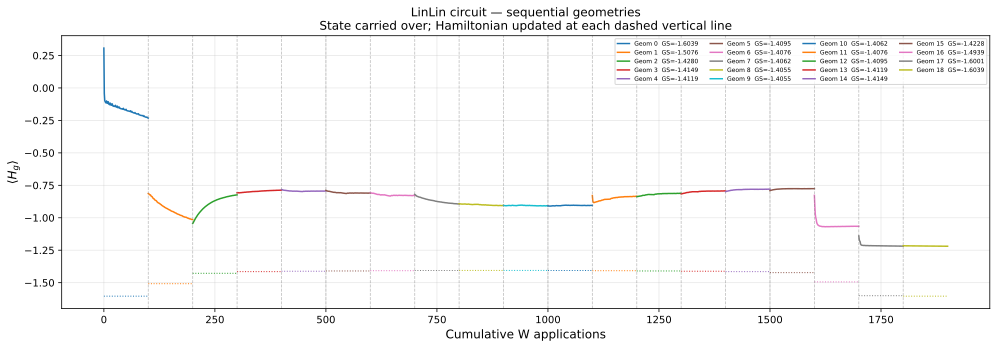

In [50]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))

global_step = 0
cmap = plt.get_cmap('tab10')

for g_idx, (steps_g, energies_g, E_corr_g) in enumerate(
    zip(all_steps, all_energies, all_E_corr)
):
    xs    = [global_step + s for s in steps_g]
    color = cmap(g_idx % 10)

    ax.plot(xs, energies_g, lw=1.5, color=color,
            label=f'Geom {g_idx}  GS={E_corr_g:.4f}')

    # Dotted horizontal line = exact GS for this geometry
    ax.hlines(E_corr_g, xs[0], xs[-1], colors=color, linestyles=':', lw=1.0)

    # Vertical dashed line at each Hamiltonian switch
    if g_idx > 0:
        ax.axvline(global_step, color='gray', lw=0.8, ls='--', alpha=0.5)

    global_step += steps_g[-1]

ax.set_xlabel('Cumulative W applications', fontsize=12)
ax.set_ylabel(r'$\langle H_g \rangle$', fontsize=12)
ax.set_title(
    'LinLin circuit — sequential geometries\n'
    'State carried over; Hamiltonian updated at each dashed vertical line',
    fontsize=12
)
ax.legend(fontsize=6, ncol=4, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [66]:
all_rhos

[]

In [17]:
rho_current =hf_density_from_occupations(
        len(system_qubits),
        [0, 1, 2, 3],
    )

all_circuits = []
all_resources = []
all_rhos = []
all_steps = []
all_energies = []
all_E_corr = []
all_E_N = []
all_E_NaNb = []

geometries = [[('H', (-2.3367346938775513, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (2.4032653061224485, 0.0, 0.0))]]

for g_idx, geometry in enumerate(geometries):

    Ham = HamiltonianBuilder().build_molecule(
        geometry=geometry,
        basis="sto-3g",
        multiplicity=2,
        charge=0,
        active_indices=None,
        ancilla_index=0,
        n_active_electrons=None,
        n_active_orbitals=None,
        use_casscf_orbitals=True,
    )
    
    # Correct electron sector for neutral H3 doublet
    n_electrons = 4

    # Fixed total-particle-number sector
    basis_N = basis_fixed_N(n_system, n_electrons)
    E_N, eigvals_N = ground_energy_in_subspace(H_mat, basis_N)

    # Fixed alpha/beta sector for doublet H3: N_alpha = 2, N_beta = 1
    basis_NaNb = basis_alpha_beta(n_system, Na=2, Nb=1)
    E_NaNb, eigvals_NaNb = ground_energy_in_subspace(H_mat, basis_NaNb)

    #print(f"Full Fock-space ground = {E_corr:.10f} Hartree")
    print(f"Fixed N={n_electrons} ground = {E_N:.10f} Hartree")
    print(f"Fixed Na=2, Nb=1 ground = {E_NaNb:.10f} Hartree")

    interaction_ham, fermion_ham, qubit_ham, H_mat, E_corr, n_system, ancilla, system_qubits = (
        Ham.interaction,
        Ham.fermion,
        Ham.qubit,
        Ham.matrix,
        Ham.energy,
        Ham.n_system,
        Ham.ancilla,
        Ham.system_qubits,
    )

    print(f"Geometry {g_idx}: {geometry}")
    print(f"E_corr = {E_corr:.10f} Hartree")

    steps, energies, W_circuits, rho_current = run_W_chain_circuit(
        system_qubits=system_qubits,
        H_int=interaction_ham,
        anc=ancilla,
        tau=1,
        filter_terms=filter_terms,
        pairs=pairs,
        weights=weights,
        N_applications=200,
        reps_per_W=20,
        occ_spin_orbs=[0, 1, 2, 3],
        trotter_steps_H=1,
        rng_seed=123 + g_idx,
        T_filter=T_filter,
        H_mat_sys=H_mat,
        initial_rho_sys=rho_current,
    )

    geometry_resources = []

    for c_idx, W_circuit in enumerate(W_circuits):
        resources = estimate_resources(W_circuit)
        geometry_resources.append(resources)

    all_circuits.append(W_circuits)
    all_resources.append(geometry_resources)
    all_rhos.append(rho_current)
    all_steps.append(steps)
    all_energies.append(energies)
    all_E_corr.append(E_corr)
    all_E_N.append(E_N)
    all_E_NaNb.append(E_NaNb)

Fixed N=4 ground = -1.1447323647 Hartree
Fixed Na=2, Nb=1 ground = -1.4054540802 Hartree
Geometry 0: [('H', (-2.3367346938775513, 0.0, 0.0)), ('H', (0.0, 0.0, 0.0)), ('H', (2.4032653061224485, 0.0, 0.0))]
E_corr = -1.4054540802 Hartree
initial circuit energy = -0.7892147694
step   1
energy = -0.8759768272566857
step   2
energy = -0.9124348487367696
step   3
energy = -0.9293785190860817
step   4
energy = -0.9382059267854516
step   5
energy = -0.9437812977112847
step   6
energy = -0.9522072166765045
step   7
energy = -0.958823937397874
step   8
energy = -0.9630590341338624
step   9
energy = -0.9689160717615573
step  10
energy = -0.9763527155090082
step  11
energy = -0.983199447178886
step  12
energy = -0.9871913431350714
step  13
energy = -0.988529736764585
step  14
energy = -0.99312814149326
step  15
energy = -0.998054667898579
step  16
energy = -0.9980029999964799
step  17
energy = -0.9983141981873754
step  18
energy = -1.0003960321419934
step  19
energy = -1.0015860805605725
step  20


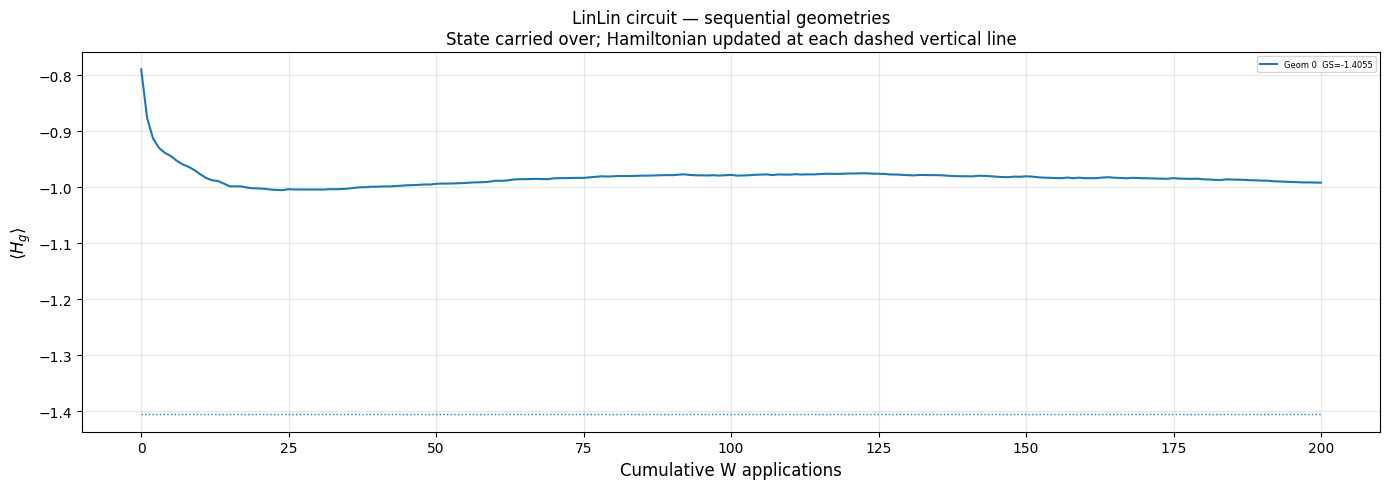

In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))

global_step = 0
cmap = plt.get_cmap('tab10')

for g_idx, (steps_g, energies_g, E_corr_g) in enumerate(
    zip(all_steps, all_energies, all_E_corr)
):
    xs    = [global_step + s for s in steps_g]
    color = cmap(g_idx % 10)

    ax.plot(xs, energies_g, lw=1.5, color=color,
            label=f'Geom {g_idx}  GS={E_corr_g:.4f}')

    # Dotted horizontal line = exact GS for this geometry
    ax.hlines(E_corr_g, xs[0], xs[-1], colors=color, linestyles=':', lw=1.0)

    # Vertical dashed line at each Hamiltonian switch
    if g_idx > 0:
        ax.axvline(global_step, color='gray', lw=0.8, ls='--', alpha=0.5)

    global_step += steps_g[-1]

ax.set_xlabel('Cumulative W applications', fontsize=12)
ax.set_ylabel(r'$\langle H_g \rangle$', fontsize=12)
ax.set_title(
    'LinLin circuit — sequential geometries\n'
    'State carried over; Hamiltonian updated at each dashed vertical line',
    fontsize=12
)
ax.legend(fontsize=6, ncol=4, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# QPE

In [ ]:
'''import numpy as np
import cirq
import openfermion as of
from openfermion.chem import MolecularData
from openfermionpyscf import run_pyscf
from scipy.linalg import expm

# ==========================================
# 1. DEFINE GEOMETRY AND GET H2 HAMILTONIAN
# ==========================================
# H2 geometry: Two Hydrogen atoms at their equilibrium distance (~0.74 Å)
bond_length = 0.7414
geometry = [('H', (0., 0., 0.)), ('H', (0., 0., bond_length))]
basis = 'sto-3g'
multiplicity = 1
charge = 0

# Generate molecular data using OpenFermion-PySCF
molecule = MolecularData(geometry, basis, multiplicity, charge)
molecule = run_pyscf(molecule, run_scf=1, run_fci=1)

# Get Molecular Hamiltonian and map to Qubit operators via Jordan-Wigner
molecular_hamiltonian = molecule.get_molecular_hamiltonian()
qubit_hamiltonian = of.jordan_wigner(molecular_hamiltonian)

# Convert OpenFermion qubit Hamiltonian to a dense matrix for simulation
# STO-3G uses 4 spin-orbitals -> 4 qubits
num_target_qubits = of.count_qubits(qubit_hamiltonian)
h_matrix = of.get_sparse_operator(qubit_hamiltonian).toarray()

print(f"FCI Ground State Energy (Exact): {molecule.fci_energy:.5f} Hartree\n")

# ==========================================
# 2. UNITARY TIME EVOLUTION COMPONENT
# ==========================================
# Select time parameter tau such that eigenvalues map uniquely to [0, 1)
# The phase will be theta = -E * tau / (2 * pi). We want 0 <= theta < 1
tau = 0.5 

# Construct the exact unitary U = exp(-i * H * tau)
u_matrix = expm(-1j * h_matrix * tau)
u_gate = build_U_H_trotter(qubit_hamiltonian, time_s=0.1, trotter_steps_H=1)

# ==========================================
# 3. CONSTRUCT QPE CIRCUIT IN CIRQ
# ==========================================
num_estimation_qubits = 8  # Controls energy resolution precision

# Define registers
estimation_qubits = cirq.LineQubit.range(num_estimation_qubits)
target_qubits = [cirq.GridQubit(0, i) for i in range(num_target_qubits)]

circuit = cirq.Circuit()

# Step A: Target Register State Preparation (Hartree-Fock State)
# H2 in STO-3G has 2 electrons filling the lowest 2 spin-orbitals
# In Jordan-Wigner, this is represented by state |1100>
circuit.append([cirq.X(target_qubits[0]), cirq.X(target_qubits[1])])

# Step B: Superposition on estimation qubits
circuit.append(cirq.H.on_each(*estimation_qubits))

# Step C: Controlled U^(2^j) operations
for i in range(num_estimation_qubits):
    controlled_u = u_gate.on(*target_qubits).controlled_by(estimation_qubits[i])
    circuit.append(controlled_u ** (2**i))

# Step D: Inverse QFT on estimation register
circuit.append(cirq.qft(*estimation_qubits, without_reverse=True) ** -1)

# Step E: Measurement
circuit.append(cirq.measure(*estimation_qubits, key='energy_phase'))

# ==========================================
# 4. RUN SIMULATION & EXTRACT ENERGY
# ==========================================
simulator = cirq.Simulator()
result = simulator.run(circuit, repetitions=500)

# Extract the most frequent bitstring outcome (the mode)
measured_mode = result.data['energy_phase'].mode()

# Convert the measured bit value to a phase value theta in [0, 1)
estimated_theta = measured_mode / (2 ** num_estimation_qubits)

counts = result.histogram(key="energy_phase")

measured_mode = max(counts, key=counts.get)

estimated_theta = measured_mode / (2 ** num_estimation_qubits)

if estimated_theta > 0.5:
    estimated_theta -= 1.0

estimated_energy = -2 * np.pi * estimated_theta / tau

print("--- QPE Results ---")
print(f"Measured mode decimal value:     {measured_mode}")
print(f"Estimated Phase (theta):         {estimated_theta:.5f}")
print(f"Calculated Ground State Energy:  {estimated_energy:.5f} Hartree")
print(f"Absolute Error:                  {abs(estimated_energy - molecule.fci_energy):.5f} Hartree")'''


FCI Ground State Energy (Exact): -1.13727 Hartree



TypeError: build_U_H_trotter() missing 1 required positional argument: 'time_s'

In [ ]:
#circuit

(0, 0): ───X───#2───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────#2─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────#2────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────#2───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────#2───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────#2─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────#2────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────#2─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
